In [36]:
import pandas as pd
import numpy as np
import pypsa
from pathlib import Path
import matplotlib.pyplot as plt

In [18]:
template = 'base_s_50__168H-T-H-B-I-A-dist1{}_2030_free{}_endo.nc'

In [19]:
sector_opts = [
    '',
    '-gas+Generator+m1.1',
    '-gas+Generator+m1.2',
    '-gas+Generator+m1.3',
    '-gas+Generator+m1.4',
]

In [20]:
tyndp_scenarios = [
    '',
    '+carbonprice-50',
    '+carbonprice-90',
    '+carbonprice-130',
]

In [21]:
idx = pd.IndexSlice

In [22]:
def get_gas_consumption(n):
    return n.statistics.energy_balance().loc[idx[:,'gas',:]].iloc[0] / 1e6

In [23]:
from itertools import product

data = pd.DataFrame(index=sector_opts, columns=tyndp_scenarios)

for sector_opt, tyndp_scenario in product(sector_opts, tyndp_scenarios):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / template.format(sector_opt, tyndp_scenario)
    )
    data.loc[sector_opt, tyndp_scenario] = get_gas_consumption(n)

data.loc[sector_opts, tyndp_scenarios]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-50_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-90_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-130_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1-gas+Generator+m1.1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H

,,+carbonprice-50,+carbonprice-90,+carbonprice-130
,3318.624602,1951.545538,1296.365353,860.888863
-gas+Generator+m1.1,2890.856541,1710.081278,1198.194594,786.198749
-gas+Generator+m1.2,2589.799142,1516.565437,949.504935,729.377742
-gas+Generator+m1.3,2294.178989,1306.135916,868.289883,633.31119
-gas+Generator+m1.4,1959.827712,1207.185942,802.788554,524.380863


In [24]:
base_n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc'
)
base_gas_cost = base_n.generators.loc[base_n.generators.carrier == 'gas', 'marginal_cost'].iloc[0]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [30]:
def household_cost_burden(
    carbon_price_eur_per_tco2,
    gas_tax_eur_per_mwh,
    gas_consumption_mwh=15,
    oil_consumption_mwh=10,
    ef_gas=0.2,
    ef_oil=0.27
    ):
    """
    Annual household cost burden from a carbon tax and/or gas tax.

    Parameters
    ----------
    carbon_price_eur_per_tco2 : float – carbon tax in €/tCO₂
    gas_tax_eur_per_mwh       : float – gas-specific tax in €/MWh
    gas_consumption_mwh       : float – household gas use (default 15 MWh/yr)
    oil_consumption_mwh       : float – household oil/petrol use (default 10 MWh/yr)
    ef_gas                    : float – emission factor gas (default 0.2 tCO₂/MWh)
    ef_oil                    : float – emission factor oil (default 0.27 tCO₂/MWh)

    Returns
    -------
    dict with carbon_tax_cost, gas_tax_cost, and total_cost (all €/yr)
    """
    carbon_tax_cost = carbon_price_eur_per_tco2 * (
        gas_consumption_mwh * ef_gas + oil_consumption_mwh * ef_oil
    )
    gas_tax_cost = gas_tax_eur_per_mwh * gas_consumption_mwh
    return {
        "carbon_tax_cost": round(carbon_tax_cost, 2),
        "gas_tax_cost": round(gas_tax_cost, 2),
        "total_cost": round(carbon_tax_cost + gas_tax_cost, 2),
    }

In [31]:
consumption = data.copy()

def get_carbonprice(x):
    if x == '':
        return 0
    else:
        return int(x.split('-')[1])

def get_gas_tax(x):
    if x == '':
        return 0
    else:
        return float(x.split('+m')[1]) * base_gas_cost - base_gas_cost



consumption.columns = list(map(get_carbonprice, consumption.columns))
consumption.index = list(map(get_gas_tax, consumption.index))

consumption

,0,50,90,130
0.000000,3318.624602,1951.545538,1296.365353,860.888863
2.457832,2890.856541,1710.081278,1198.194594,786.198749
4.915665,2589.799142,1516.565437,949.504935,729.377742
7.373497,2294.178989,1306.135916,868.289883,633.31119
9.831330,1959.827712,1207.185942,802.788554,524.380863


In [38]:
burden = pd.DataFrame(index=consumption.index, columns=consumption.columns)

for i in range(len(consumption.index)):
    for j in range(len(consumption.columns)):
        burden.iloc[i, j] = household_cost_burden(consumption.index[i], consumption.columns[j])['total_cost']

burden

,0,50,90,130
0.000000,0.0,750.0,1350.0,1950.0
2.457832,14.01,764.01,1364.01,1964.01
4.915665,28.02,778.02,1378.02,1978.02
7.373497,42.03,792.03,1392.03,1992.03
9.831330,56.04,806.04,1406.04,2006.04


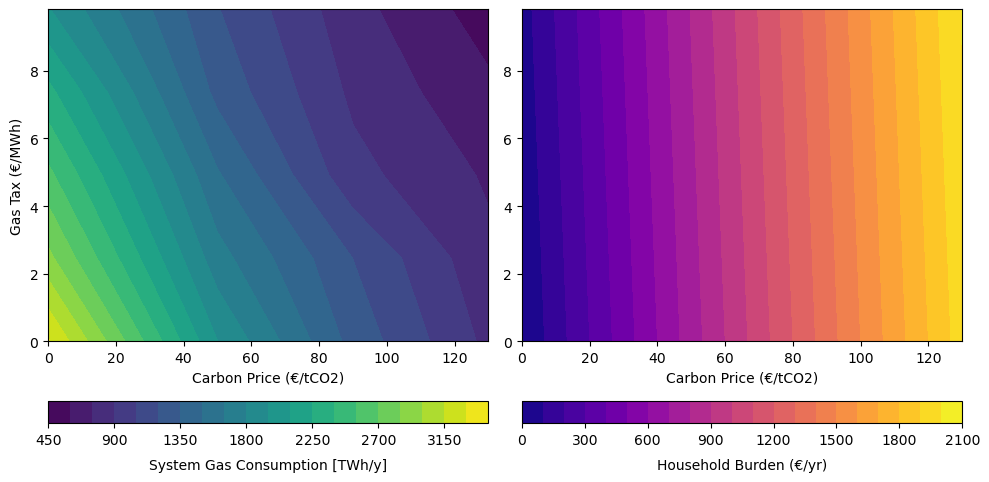

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Ensure values are float and no dtype issues
consumption_np = consumption.values.astype(float)
burden_np = burden.values.astype(float)

# Plot consumption as a contourplot in first axis
X, Y = np.meshgrid(consumption.columns.values.astype(float), consumption.index.values.astype(float))
cf1 = ax[0].contourf(X, Y, consumption_np, levels=20, cmap="viridis")
cb1 = plt.colorbar(cf1, ax=ax[0], orientation="horizontal", pad=0.13)
cb1.set_label("System Gas Consumption [TWh/y]", fontsize=10, labelpad=8)
ax[0].set_xlabel("Carbon Price (€/tCO2)")
ax[0].set_ylabel("Gas Tax (€/MWh)")

# Plot burden as a contourplot in second axis
cf2 = ax[1].contourf(X, Y, burden_np, levels=20, cmap="plasma")
cb2 = plt.colorbar(cf2, ax=ax[1], orientation="horizontal", pad=0.13)
cb2.set_label("Household Burden (€/yr)", fontsize=10, labelpad=8)
ax[1].set_xlabel("Carbon Price (€/tCO2)")
# ax[1].set_ylabel("Gas Tax (€/MWh)")

plt.tight_layout()
plt.show()

In [4]:
m.generators.loc[n.generators.carrier == 'gas', 'marginal_cost'].head()

Generator
AT0 0 gas    27.0248
BE0 0 gas    27.0248
BG0 0 gas    27.0248
CZ0 0 gas    27.0248
DE0 0 gas    27.0248
Name: marginal_cost, dtype: float64